___________________________
## Real Estate Price Predictor
___________________________

In [13]:
# Collecting Requirements

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,r2_score

_________________________________
###  Loading Data
___________________________

In [2]:
df = pd.read_csv('../Data/Housing.csv')

______________________
### Data Overview
_________________________

In [3]:
df.sample(5)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
1346,1347,Delhi,Dwarka,Locality_84,Villa,5,2978,166.40,0.06,2023,...,2,3,4,High,Yes,Yes,"Pool, Garden, Clubhouse, Playground, Gym",East,Broker,Ready_to_Move
37855,37856,Bihar,Gaya,Locality_54,Villa,2,2140,330.54,0.15,1990,...,35,4,3,Medium,Yes,No,"Pool, Gym, Playground",North,Broker,Under_Construction
46394,46395,Haryana,Faridabad,Locality_435,Villa,3,3589,338.71,0.09,2002,...,23,4,2,High,Yes,Yes,"Clubhouse, Garden, Pool",North,Builder,Ready_to_Move
213282,213283,Madhya Pradesh,Indore,Locality_40,Independent House,2,2152,10.80,0.01,2013,...,12,8,7,High,Yes,No,"Playground, Clubhouse, Pool, Garden",North,Owner,Ready_to_Move
44312,44313,Haryana,Gurgaon,Locality_102,Apartment,4,3194,297.91,0.09,2008,...,17,7,8,Low,Yes,No,"Gym, Clubhouse, Garden, Playground, Pool",North,Broker,Ready_to_Move


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  str    
 2   City                            250000 non-null  str    
 3   Locality                        250000 non-null  str    
 4   Property_Type                   250000 non-null  str    
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  str    
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors               

## Data Cleaning

________________________________
#### > Cheking Null Values in Data
________________________________

In [5]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

_________________________________
#### > Cheking for Duplicate Data
__________________________________

In [6]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

___________________________________
#### > Target Column = Price_in_Lakhs
___________________________________

In [4]:
df['Price_in_Lakhs'].describe()

count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

______________________________________
###    - Target Variable Distribution
_________________________________

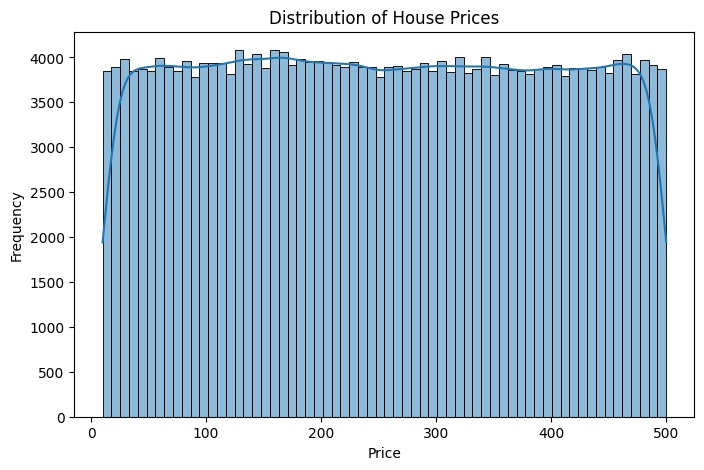

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price_in_Lakhs'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [17]:
df.skew

<bound method DataFrame.skew of             ID        State       City      Locality      Property_Type  BHK  \
0            1   Tamil Nadu    Chennai   Locality_84          Apartment    1   
1            2  Maharashtra       Pune  Locality_490  Independent House    3   
2            3       Punjab   Ludhiana  Locality_167          Apartment    2   
3            4    Rajasthan    Jodhpur  Locality_393  Independent House    2   
4            5    Rajasthan     Jaipur  Locality_466              Villa    4   
...        ...          ...        ...           ...                ...  ...   
249995  249996      Gujarat  Ahmedabad  Locality_187  Independent House    5   
249996  249997   Tamil Nadu    Chennai  Locality_348          Apartment    1   
249997  249998    Telangana   Warangal  Locality_225              Villa    4   
249998  249999       Odisha    Cuttack  Locality_138              Villa    1   
249999  250000      Haryana    Gurgaon  Locality_268  Independent House    3   

       

The distribution of house prices is relatively uniform across the dataset, with no significant skewness or extreme outliers. This indicates a balanced target variable suitable for regression modeling.

________________________________
### Correlation Analysis
________________________________

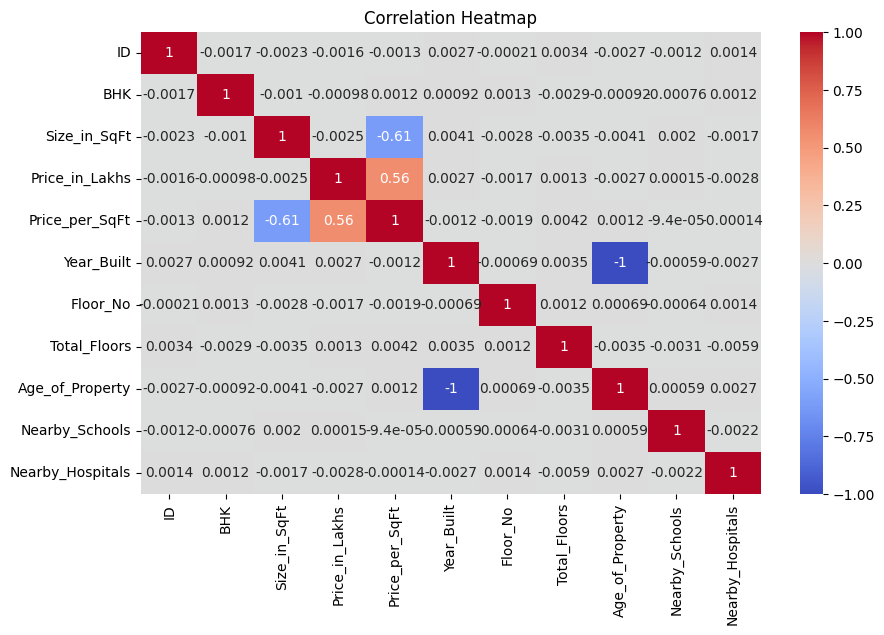

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [29]:
corr_with_price = df.corr(numeric_only=True)['Price_in_Lakhs']

corr_with_price.sort_values(ascending=False)

Price_in_Lakhs      1.000000
Price_per_SqFt      0.555625
Year_Built          0.002714
Total_Floors        0.001283
Nearby_Schools      0.000155
BHK                -0.000980
ID                 -0.001636
Floor_No           -0.001719
Size_in_SqFt       -0.002529
Age_of_Property    -0.002714
Nearby_Hospitals   -0.002769
Name: Price_in_Lakhs, dtype: float64

The correlation analysis shows that Price_per_SqFt has the strongest positive relationship with house price (0.56), indicating that properties with a higher price per square foot tend to have higher overall prices. Other features show very weak correlations with the target variable, suggesting a limited linear relationship with house prices.

_____________________________
### Feature Relationships
___________________________

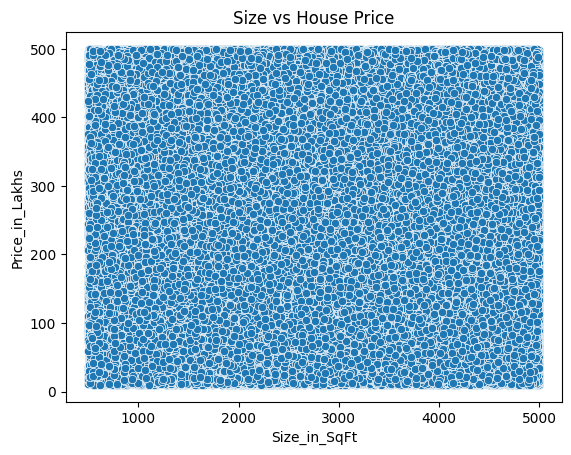

In [30]:
# Area/Size VS Price

sns.scatterplot(
    data=df,
    x='Size_in_SqFt',
    y='Price_in_Lakhs'
)

plt.title("Size vs House Price")
plt.show()

The scatter plot shows a weak relationship between property size and house price. The data points are widely dispersed with no clear trend, indicating that Size_in_SqFt alone is not a strong predictor of house prices in this dataset. This suggests that other factors may have a greater influence on property prices.

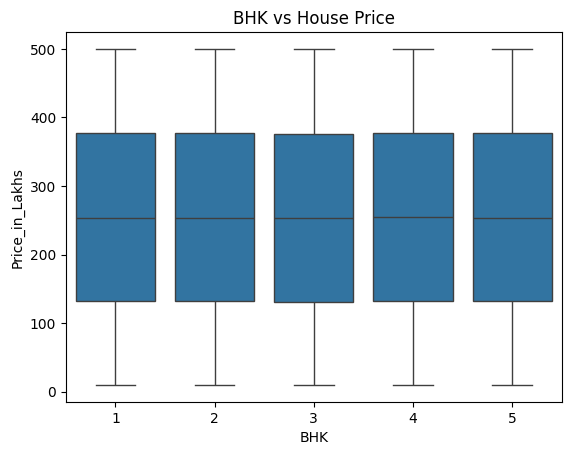

In [31]:
# BHK VS Price

sns.boxplot(
    data=df,
    x='BHK',
    y='Price_in_Lakhs'
)

plt.title("BHK vs House Price")
plt.show()

The box plot shows that house prices are distributed similarly across all BHK categories. The median price and spread remain nearly constant, indicating that the number of bedrooms has a weak influence on house prices in this dataset.

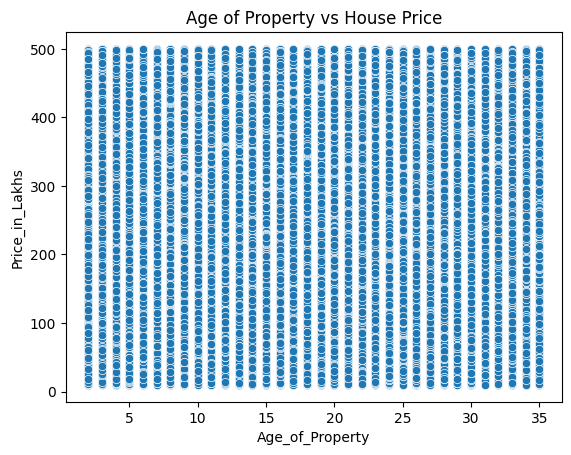

In [32]:
# Age of Property VS Price

sns.scatterplot(
    data=df,
    x='Age_of_Property',
    y='Price_in_Lakhs'
)

plt.title("Age of Property vs House Price")
plt.show()

The scatter plot shows no clear relationship between the age of a property and its price. House prices remain widely distributed across all age groups, indicating that property age has a minimal impact on pricing in this dataset.

## Data Preprocessing

In [35]:
df.columns

Index(['Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs',
       'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No',
       'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security'],
      dtype='str')

In [34]:
# Droping Columns that do not have impact on the price
df = df.drop(columns=['ID', 'State', 'City', 'Locality', 'Total_Floors',  'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'])